## Hackathon triage system

At large-scale hackathons, organizers face a massive logistical bottleneck when submissions close: they must manually read, categorize, and route hundreds (or thousands) of project abstracts to the correct judging panels within a matter of hours. This manual triage is exhausting, error-prone, and delays the entire event. We need an intelligent system that uses Machine Learning to auto-categorize submissions while providing a seamless, human-in-the-loop dashboard for organizers to verify routing and a secure portal for judges to evaluate them.

In [93]:
# All Import Statements
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import ast
import re

In [94]:
#loading the dataset
data = pd.read_csv('../dataset/devpost_raw_5k.csv')

In [95]:
#analyzing the dataset
print(data.head())
print("data info: \n",data.info())

   hackathon_id                                       project_link  \
0          8834  https://devpost.com/software/where-s-my-groceries   
1          9854          https://devpost.com/software/virgo-lzunfp   
2         11286    https://devpost.com/software/endangered-species   
3         15774  https://devpost.com/software/pneumonia-identif...   
4         12948  https://devpost.com/software/revfit-abstract-a...   

                                           full_desc  \
0  Inspiration\n\nI was shopping with my friend a...   
1  Inspiration\n\nmy inspiration is derived from ...   
2  Our Rooms\n\nThe chat \n\nLogin\n\nInspiration...   
3  Inspiration\n\nEvery year in India around 200-...   
4  We wanted to spread our love for fitness and h...   

                      title  \
0     Where's my groceries?   
1                     VIRGO   
2        Endangered Species   
3  Pneumonia Identification   
4  RevFit Abstract Assasins   

                                          brief_desc  \

# data cleaning and preprocessing

In [96]:

#checking for missing values

print("Missing values in each column: \n",data.isnull().sum())

Missing values in each column: 
 hackathon_id    0
project_link    0
full_desc       2
title           1
brief_desc      7
team_members    0
prize           0
tags            0
dtype: int64


In [97]:
data.dropna(inplace=True)

In [98]:
data.isnull().sum()

hackathon_id    0
project_link    0
full_desc       0
title           0
brief_desc      0
team_members    0
prize           0
tags            0
dtype: int64

In [99]:
duplicates = data.duplicated(subset=['title']).sum()
print("\nNumber of duplicate titles: ", duplicates)


Number of duplicate titles:  55


In [100]:
data.drop_duplicates(subset=['title'], inplace=True)

In [101]:
duplicates = data.duplicated(subset=['title']).sum()
print("\nNumber of duplicate titles: ", duplicates)


Number of duplicate titles:  0


In [102]:
# 2. Compact Parser Function
def parse_list(val):
    try:
        return ast.literal_eval(val) if pd.notna(val) else []
    except (ValueError, SyntaxError):
        return []

# 3. Apply to columns
data['parsed_tags'] = data['tags'].apply(parse_list)
data['parsed_team'] = data['team_members'].apply(parse_list)

print(data[['title', 'parsed_tags', 'parsed_team']].head())

                      title  \
0     Where's my groceries?   
1                     VIRGO   
2        Endangered Species   
3  Pneumonia Identification   
4  RevFit Abstract Assasins   

                                         parsed_tags  \
0                                                 []   
1                                       [javascript]   
2  [bootstrap, css3, html5, java, javascript, spr...   
3  [css3, deeplearning, flask, html5, javascript,...   
4                              [firebase, thunkable]   

                               parsed_team  
0                             [clincl Lin]  
1  [Musundi Gilbert Bruno, Emitu Shamrock]  
2           [Keerthi Kalyaan, Aron Thakur]  
3       [VIDYA SRI ., NELAVETLA VAISHNAVI]  
4         [Rajvir Mishra, Saranya Agrawal]  


In [103]:
# Cleaning text data
def clean_html(text):
    # Handle NaN or missing values
    if not isinstance(text, str):
        return ""
    
    # 1. Replace HTML tags with a space (e.g., <p>, <br>, <strong>)
    text = re.sub(r'<[^>]+>', ' ', text)
    
    # 2. Remove URLs (anything starting with http or https)
    text = re.sub(r'http\S+', '', text)
    
    # 3. Remove extra whitespace left behind by the replacements
    text = re.sub(r'\s+', ' ', text)
    
    return text.strip()

data['clean_abstract'] = data['full_desc'].apply(clean_html)

# Let's verify it worked by checking the original vs the clean version
print("--- ORIGINAL ---")
print(data['full_desc'].iloc[0][:150])

print("\n--- CLEANED ---")
print(data['clean_abstract'].iloc[0][:150])

--- ORIGINAL ---
Inspiration

I was shopping with my friend and she couldn't find Queso at Wegmans.

What it does

You text to a number for information!

How I built i

--- CLEANED ---
Inspiration I was shopping with my friend and she couldn't find Queso at Wegmans. What it does You text to a number for information! How I built it I 


In [104]:
def assign_track(row):
    # Combine the abstract and the parsed tags into one lowercase string for easy searching
    content = str(row['clean_abstract']).lower() + " " + " ".join(row['parsed_tags']).lower()
    
    # 1. AI / ML
    if any(kw in content for kw in ['machine learning', 'artificial intelligence', 'deep learning', 'nlp', 'computer vision']) or ' ai ' in f" {content} ":
        return 'AI/ML'
        
    # 2. Web3 / Blockchain
    elif any(kw in content for kw in ['blockchain', 'web3', 'crypto', 'nft', 'ethereum', 'smart contract', 'solana']):
        return 'Web3/Blockchain'
        
    # 3. HealthTech
    elif any(kw in content for kw in ['health', 'medical', 'healthcare', 'doctor', 'patient', 'hospital', 'fitness']):
        return 'HealthTech'
        
    # 4. Hardware / IoT
    elif any(kw in content for kw in ['hardware', 'iot', 'arduino', 'raspberry pi', 'sensor', 'robotics', 'microcontroller']):
        return 'Hardware/IoT'
        
    # 5. Web / Mobile (NOW HAS EXPLICIT KEYWORDS)
    elif any(kw in content for kw in ['react', 'angular', 'vue', 'ios', 'android', 'mobile app', 'web app', 'frontend', 'backend', 'fullstack', 'flutter', 'react native', 'css', 'html', 'django', 'flask']):
        return 'Web/Mobile'
        
    # 6. The True Garbage Bin
    else:
        return 'Drop'


#  Apply the function across all rows
data['target_track'] = data.apply(assign_track, axis=1)

# PURGE THE NOISE: Drop all rows that didn't fit into our 5 core tracks
original_count = len(data)
data = data[data['target_track'] != 'Drop']
print(f"\n--- Purged {original_count - len(data)} noisy projects from the training data! ---")

print("\n--- New Track Distribution ---")
print(data['target_track'].value_counts())



--- Purged 1047 noisy projects from the training data! ---

--- New Track Distribution ---
target_track
Web/Mobile         1742
AI/ML              1119
HealthTech          473
Web3/Blockchain     289
Hardware/IoT        266
Name: count, dtype: int64



--- Plotting Track Distribution ---


C:\Users\Ajeet Rawat\AppData\Local\Temp\ipykernel_22888\1887054263.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


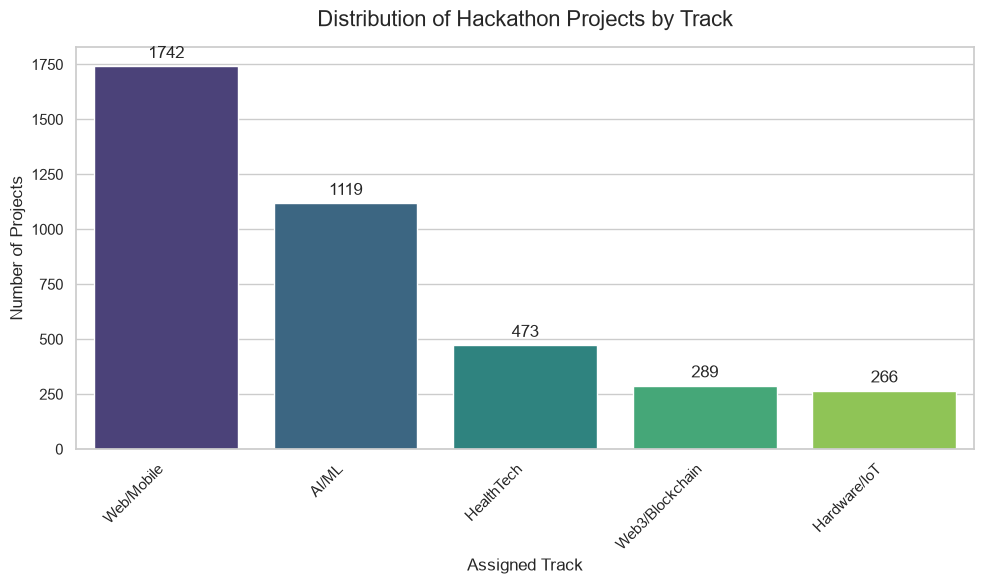

In [105]:
print("\n--- Plotting Track Distribution ---")
# Set a clean, modern aesthetic
sns.set_theme(style="whitegrid")

# Create the figure
plt.figure(figsize=(10, 6))

# Plot the counts using Seaborn
ax = sns.countplot(
    data=data, 
    x='target_track', 
    order=data['target_track'].value_counts().index, 
    palette='viridis'
)

# Add titles and labels
plt.title('Distribution of Hackathon Projects by Track', fontsize=16, pad=15)
plt.xlabel('Assigned Track', fontsize=12)
plt.ylabel('Number of Projects', fontsize=12)

# Rotate x-axis labels if they overlap
plt.xticks(rotation=45, ha='right')

# Add the exact count numbers on top of each bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points')

# Adjust layout so everything fits and display the plot
plt.tight_layout()
plt.show()

In [106]:
data.head()

,hackathon_id,project_link,full_desc,title,brief_desc,team_members,prize,tags,parsed_tags,parsed_team,clean_abstract,target_track
0,8834,https://devpost.com/software/where-s-my-groceries,Inspiration\n\nI was shopping with my friend a...,Where's my groceries?,Ever not able to find groceries at Wegmans? Us...,['clincl Lin'],[],[],[],[clincl Lin],Inspiration I was shopping with my friend and ...,Web/Mobile
1,9854,https://devpost.com/software/virgo-lzunfp,Inspiration\n\nmy inspiration is derived from ...,VIRGO,Virgo is a social interaction app where people...,"['Musundi Gilbert Bruno', 'Emitu Shamrock']",[],['javascript'],[javascript],"[Musundi Gilbert Bruno, Emitu Shamrock]",Inspiration my inspiration is derived from my ...,HealthTech
2,11286,https://devpost.com/software/endangered-species,Our Rooms\n\nThe chat \n\nLogin\n\nInspiration...,Endangered Species,"A centralized platform to raise awareness, ple...","['Keerthi Kalyaan', 'Aron Thakur']",[],"['bootstrap', 'css3', 'html5', 'java', 'javasc...","[bootstrap, css3, html5, java, javascript, spr...","[Keerthi Kalyaan, Aron Thakur]",Our Rooms The chat Login Inspiration All of us...,Web/Mobile
3,15774,https://devpost.com/software/pneumonia-identif...,Inspiration\n\nEvery year in India around 200-...,Pneumonia Identification,Pneumonia Detection from Chest X-rays using CNN,"['VIDYA SRI .', 'NELAVETLA VAISHNAVI']",[],"['css3', 'deeplearning', 'flask', 'html5', 'ja...","[css3, deeplearning, flask, html5, javascript,...","[VIDYA SRI ., NELAVETLA VAISHNAVI]",Inspiration Every year in India around 200-300...,AI/ML
4,12948,https://devpost.com/software/revfit-abstract-a...,We wanted to spread our love for fitness and h...,RevFit Abstract Assasins,Our app motivates people to begin or continue ...,"['Rajvir Mishra', 'Saranya Agrawal']",[],"['firebase', 'thunkable']","[firebase, thunkable]","[Rajvir Mishra, Saranya Agrawal]",We wanted to spread our love for fitness and h...,HealthTech


In [107]:
# print("\n--- Balancing the Dataset before Training ---")
# # Find how many rows the smallest class has
# min_class_size = data['target_track'].value_counts().min()
# print(f"Downsampling all classes to exactly {min_class_size} rows...")

# # Group by track and sample equally
# df_balanced = data.groupby('target_track').sample(n=min_class_size, random_state=42)

## Model Training

In [108]:
#importing libraries for model training
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
import joblib

In [109]:
print("\n--- Training Machine Learning Model ---")

# 1. Define our features (X) and labels (y)
X = data['clean_abstract']
y = data['target_track']

# 2. Split the data (80% for training, 20% for testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


--- Training Machine Learning Model ---


In [110]:
# Creating a Scikit-Learn Pipeline
# TF-IDF converts text into numbers (ignoring common English stop words)
# LinearSVC is a very fast and accurate algorithm for text classification
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('clf', LinearSVC(class_weight='balanced', random_state=42, dual=False, max_iter=2000))
])
#    Define the "Grid" of Hyperparameters to test
# The dictionary keys must match the step name + '__' + the parameter name
param_grid = {
    'tfidf__ngram_range': [(1, 1), (1, 2)], # Test single words vs. two-word phrases
    'tfidf__max_df': [0.5, 0.75, 1.0],      # Test how aggressively to ignore common words
    'tfidf__min_df': [1, 3],                # Test ignoring rare typos vs keeping everything
    'clf__C': [0.1, 1.0, 10.0]              # Test different regularization strengths
}

In [111]:
# Initialize GridSearchCV
# cv=3 means it will cross-validate 3 times for EVERY combination
# n_jobs=-1 tells it to use all of your computer's CPU cores to run faster
print(f"Starting Grid Search across {len(param_grid['tfidf__ngram_range']) * len(param_grid['tfidf__max_df']) * len(param_grid['tfidf__min_df']) * len(param_grid['clf__C'])} combinations...")
print("This might take a minute or two, please wait...")
grid_search = GridSearchCV(pipeline, param_grid, cv=3, n_jobs=-1, verbose=1)

Starting Grid Search across 36 combinations...
This might take a minute or two, please wait...


In [112]:
#  Run the massive search!
grid_search.fit(X_train, y_train)

# 7. Reveal the winner
print("\n🏆 --- Best Hyperparameters Found --- 🏆")
for param_name in sorted(param_grid.keys()):
    print(f"{param_name}: {grid_search.best_params_[param_name]}")

Fitting 3 folds for each of 36 candidates, totalling 108 fits

🏆 --- Best Hyperparameters Found --- 🏆
clf__C: 1.0
tfidf__max_df: 0.5
tfidf__min_df: 3
tfidf__ngram_range: (1, 2)


In [113]:
#confusion matrix
# from sklearn.metrics import confusion_matrix , ConfusionMatrixDisplay
# cm = confusion_matrix(y_test, model_pipeline.predict(X_test))
# disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model_pipeline.classes_)
# disp.plot(cmap=plt.cm.Blues,xticks_rotation=45)
# plt.title('Confusion Matrix for Hackathon Project Track Classification', fontsize=16, pad=15)
# plt.show()

# MODEL EVALUATION

In [114]:

# Evaluate the absolute best model it found
print("\n--- Best Model Evaluation ---")
best_model = grid_search.best_estimator_
predictions = best_model.predict(X_test)
print(classification_report(y_test, predictions))


--- Best Model Evaluation ---
                 precision    recall  f1-score   support

          AI/ML       0.88      0.79      0.83       234
   Hardware/IoT       0.78      0.66      0.71        53
     HealthTech       0.75      0.57      0.65        98
     Web/Mobile       0.82      0.94      0.87       337
Web3/Blockchain       0.79      0.79      0.79        56

       accuracy                           0.82       778
      macro avg       0.80      0.75      0.77       778
   weighted avg       0.82      0.82      0.82       778



### Dumping

In [116]:
model_filename = "hackathon_model.pkl"
joblib.dump(best_model, model_filename)
print(f"\nModel successfully saved to {model_filename}! Ready for Django.")


Model successfully saved to hackathon_model.pkl! Ready for Django.
